# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

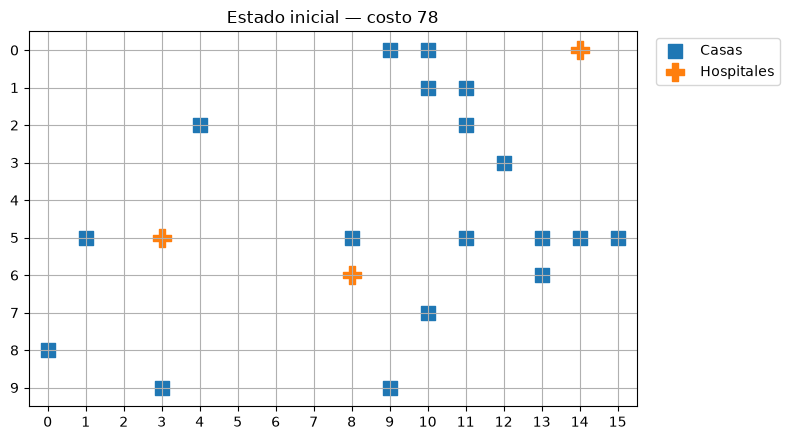

In [28]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [29]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 10
Costo actual: 78
Mejor costo vecino: 73


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 78
Costo final: 56
Iteraciones con mejora: 6


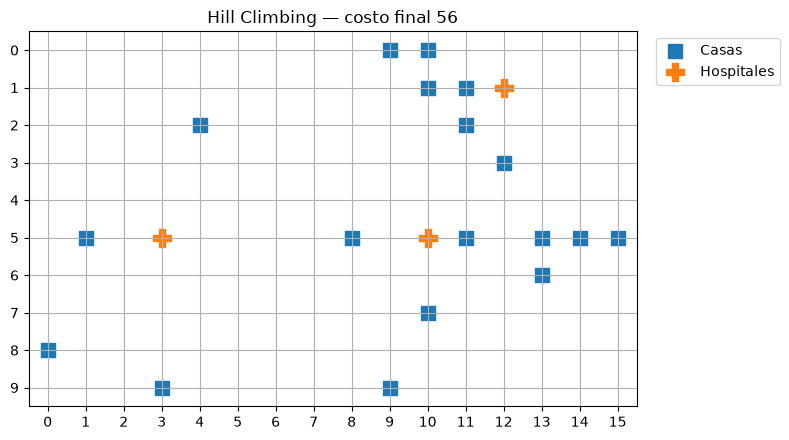

In [30]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [total_cost(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing — costo final {history[-1]}')

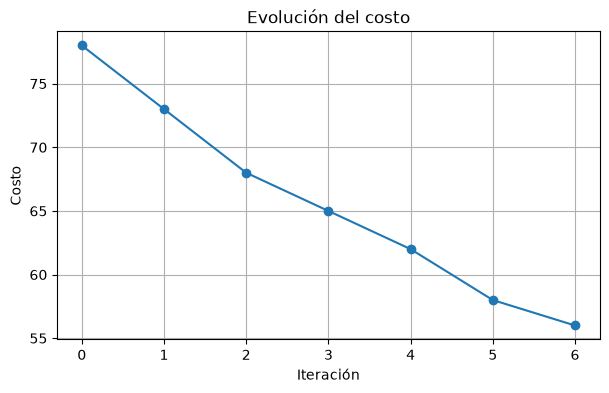

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 48
Reinicio ganador: 35


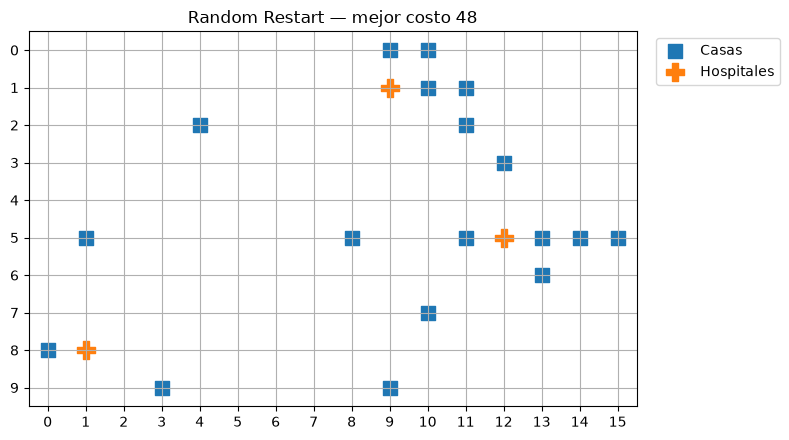

In [32]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart — mejor costo {best["final_cost"]}')

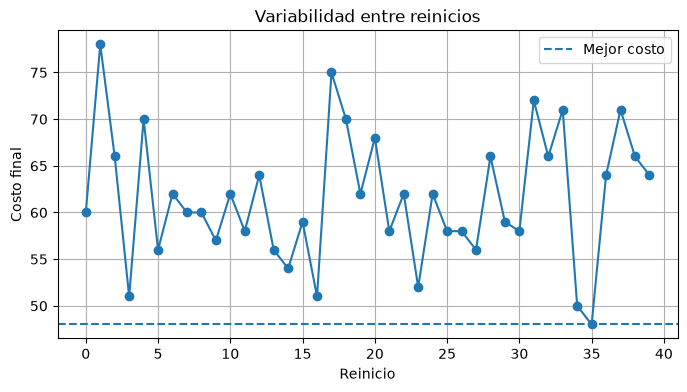

In [33]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4))
plt.plot(final_costs, marker='o')
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show()

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

In [34]:
# TODO: implementa la distancia euclídea y una nueva función de costo.
def euclidean(a, b):
    np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2
            )


def total_cost_euclidean(houses, hospitals):
    return sum(min(euclidean(house, hospital) for hospital in hospitals)
                   for house in houses)


### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

k=1: costo final = 96
k=2: costo final = 70
k=3: costo final = 48
k=4: costo final = 43
k=5: costo final = 35


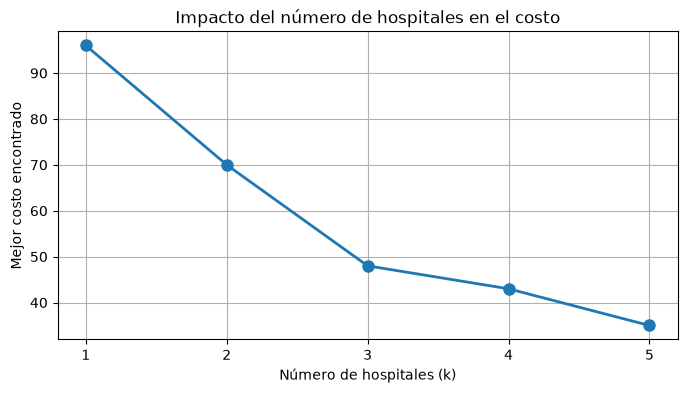


Reducción incremental:
k=1 → k=2: reducción de 26
k=2 → k=3: reducción de 22
k=3 → k=4: reducción de 5
k=4 → k=5: reducción de 8


In [35]:
results = []
for k in range(1, 6):
    best_k, _ = random_restart(HEIGHT, WIDTH, houses, k, restarts=40, seed=SEED)
    results.append((k, best_k['final_cost']))
    print(f'k={k}: costo final = {best_k["final_cost"]}')

# Visualizar resultados
plt.figure(figsize=(8, 4))
k_values, costs = zip(*results)
plt.plot(k_values, costs, marker='o', linewidth=2, markersize=8)
plt.xlabel('Número de hospitales (k)')
plt.ylabel('Mejor costo encontrado')
plt.title('Impacto del número de hospitales en el costo')
plt.grid(True)
plt.xticks(k_values)
plt.show()

# Calcular reducción incremental
print('\nReducción incremental:')
for i in range(1, len(results)):
    reduction = results[i-1][1] - results[i][1]
    print(f'k={results[i-1][0]} → k={results[i][0]}: reducción de {reduction}')

### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados?

Vecinos con distancia 1: 10
Vecinos con distancia 2: 56
Aumento: 5.60x

Resultados:
HC distancia 1 - Costo final: 56, Iteraciones: 6
HC distancia 2 - Costo final: 56, Iteraciones: 6
Mejora: 0


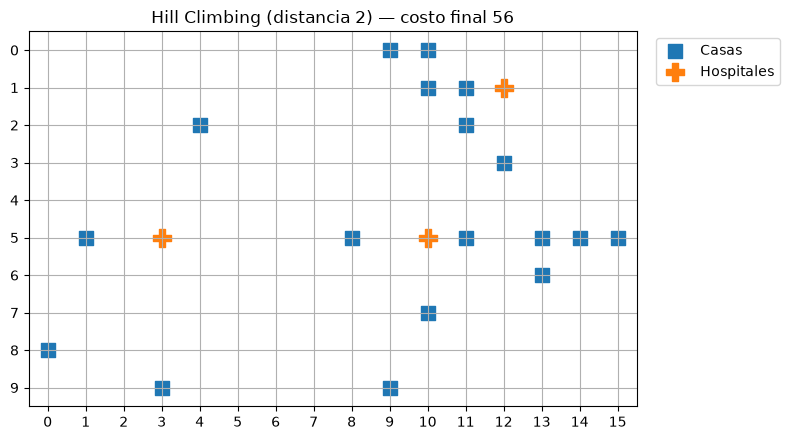

In [38]:
def neighbors_of_state_extended(height, width, houses, hospitals, max_distance=2):
    """Generate neighbors allowing hospital movements up to max_distance cells away."""
    neighbors = []
    
    for hospital in hospitals:
        for dr in range(-max_distance, max_distance + 1):
            for dc in range(-max_distance, max_distance + 1):
                if dr == 0 and dc == 0:
                    continue
                
                candidate = (hospital[0] + dr, hospital[1] + dc)
                
                # Check bounds
                if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                    continue
                
                # Check not occupied by houses or other hospitals
                if candidate in houses or candidate in hospitals:
                    continue
                
                new_state = set(hospitals)
                new_state.remove(hospital)
                new_state.add(candidate)
                neighbors.append(new_state)
    
    return neighbors

# Compare with original neighborhood (distance 1)
neighbors_dist1 = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
neighbors_dist2 = neighbors_of_state_extended(HEIGHT, WIDTH, houses, initial_hospitals, max_distance=2)

print(f"Vecinos con distancia 1: {len(neighbors_dist1)}")
print(f"Vecinos con distancia 2: {len(neighbors_dist2)}")
print(f"Aumento: {len(neighbors_dist2) / len(neighbors_dist1):.2f}x")

# Run Hill Climbing with extended neighborhood
solution_ext, history_ext, _ = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

# Compare results
print(f"\nResultados:")
print(f"HC distancia 1 - Costo final: {history[-1]}, Iteraciones: {len(history)-1}")
print(f"HC distancia 2 - Costo final: {history_ext[-1]}, Iteraciones: {len(history_ext)-1}")
print(f"Mejora: {history[-1] - history_ext[-1]}")

plot_state(HEIGHT, WIDTH, houses, solution_ext,
           title=f'Hill Climbing (distancia 2) — costo final {history_ext[-1]}')

## Preguntas de cierre

**1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?**

Hill Climbing es un algoritmo greedy que:


  • Solo explora vecinos del estado actual (en este caso, ~10-20 vecinos)


  • Espacio total posible: C(160, 3) = 669,920 configuraciones


  • Explora solo una pequeña fracción del espacio


  • Se detiene cuando no hay mejora, sin necesidad de evaluar todo




**2. ¿El resultado depende del estado inicial?**

Varianza en costos iniciales: 15.24


  • Varianza en costos finales: 6.90


  • Costos finales varían de 48 a 78


  • SÍ, el estado inicial afecta significativamente el resultado final




**3. ¿Random Restart garantiza encontrar el óptimo global?**


• Con 40 reinicios, encontramos costo: 48


  • NO garantiza óptimo global, pero aumenta probabilidad


  • Mejor ejecutar múltiples reinicios que uno solo


  • Requeriría exploración exhaustiva para garantía



**4. ¿Qué información se pierde al conservar únicamente el mejor vecino?**

 • Se pierden caminos alternativos de exploración


  • No se detectan mesetas (vecinos con costo igual)


  • No hay diversidad en la búsqueda


  • Puede quedarse atrapado en óptimos locales


  • En este ejemplo, algunos reinicios encuentran mínimos locales con costos: [48, 50, 51] (vs óptimo: 48)